<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°06


**Objetivo**: Aplicar técnicas básicas de **Machine Learning**, desde la preparación de datos hasta el entrenamiento y evaluación de modelos.




<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" width="500"/>
</p>

El **cuarteto de Anscombe** es un ejemplo clásico en estadística que ilustra cómo diferentes conjuntos de datos pueden compartir las mismas propiedades estadísticas, como media, varianza y correlación, pero presentan comportamientos muy distintos cuando se visualizan gráficamente. Cada uno de los cuatro conjuntos consiste en once puntos (x, y) y fue creado por el estadístico F. J. Anscombe en 1973. Esta herramienta resalta la importancia de la visualización de datos para evitar interpretaciones erróneas basadas únicamente en análisis numéricos.

**Descripción del conjunto**

1. **Propiedades estadísticas comunes:** Todos los conjuntos tienen el mismo valor promedio para las variables \(x\) e \(y\), la misma varianza para \(x\) e \(y\), y una correlación lineal idéntica.
2. **Diferencias gráficas:** A pesar de sus similitudes estadísticas, los cuatro conjuntos presentan gráficos muy distintos:
   - El primer conjunto muestra una relación lineal simple.
   - El segundo conjunto tiene una relación no lineal, con una curva clara.
   - El tercer conjunto tiene una relación lineal clara, pero con un punto atípico que influye significativamente.
   - El cuarto conjunto tiene la mayoría de los puntos alineados verticalmente, con un punto atípico que afecta la correlación.

Este cuarteto enfatiza que las estadísticas descriptivas por sí solas pueden no capturar la esencia completa de los datos, subrayando la necesidad de utilizar visualizaciones en cualquier análisis exploratorio de datos.

In [1]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


Con base en la información presentada y el análisis realizado, les invitamos a reflexionar y responder las siguientes preguntas. Estas preguntas están diseñadas para profundizar en su comprensión del cuarteto de Anscombe y fomentar un análisis crítico de los datos:



1. Cree un gráfico de dispersión (scatter plot) para cada uno de los cuatro grupos del cuarteto de Anscombe. A partir de la visualización, ¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?



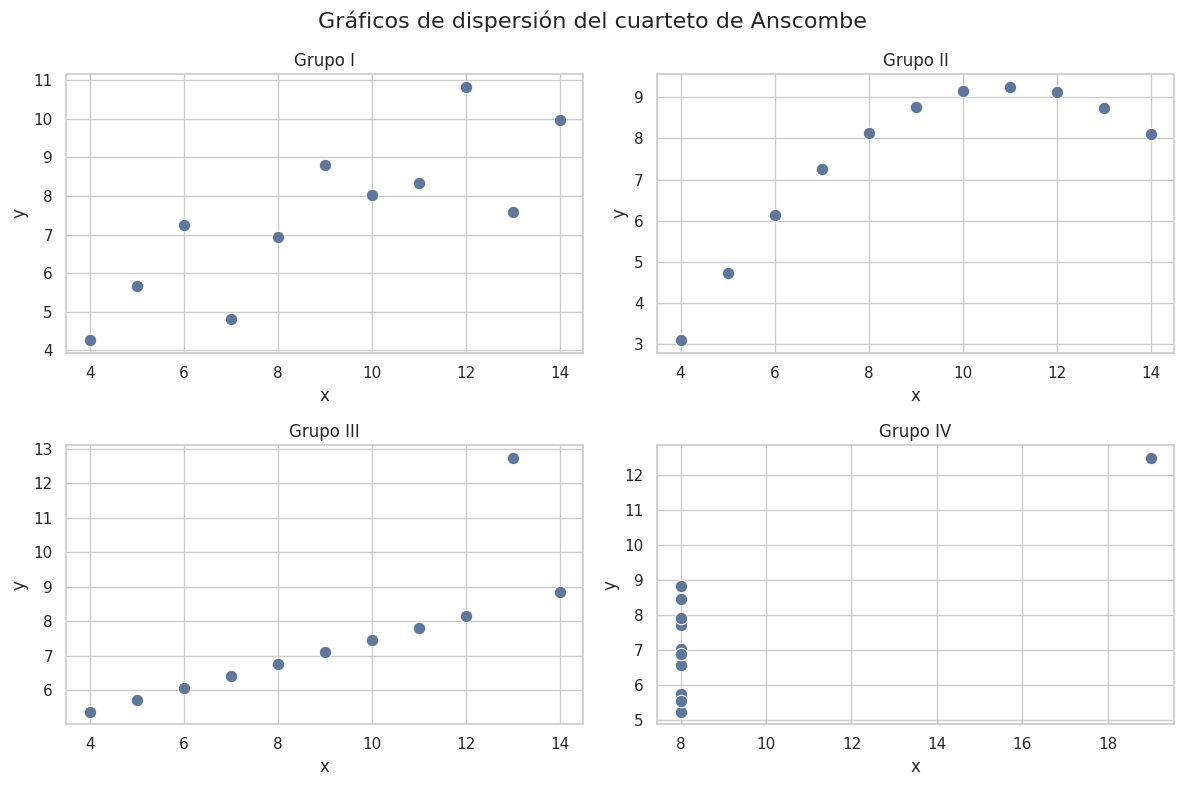

In [2]:
# 1. Gráficos de dispersión para los cuatro grupos del cuarteto de Anscombe

# Obtener nombres de los grupos
datasets = data["dataset"].unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, dataset in zip(axes, datasets):
    subset = data[data["dataset"] == dataset]

    sns.scatterplot(
        data=subset,
        x="x",
        y="y",
        ax=ax,
        s=80
    )

    ax.set_title(f"Grupo {dataset}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Gráficos de dispersión del cuarteto de Anscombe", fontsize=16)
plt.tight_layout()
plt.show()

Los gráficos de dispersión muestran que los cuatro grupos del cuarteto de Anscombe tienen comportamientos visualmente muy distintos, aunque luego se observa que comparten estadísticas similares.

En el **grupo I**, los puntos siguen una tendencia lineal positiva bastante clara, por lo que una recta parece representar razonablemente la relación entre `x` e `y`.

En el **grupo II**, los puntos no siguen una relación lineal, sino una forma curva. Esto indica que una regresión lineal simple no sería el modelo más adecuado para este grupo, ya que no captura correctamente el patrón de los datos.

En el **grupo III**, la mayoría de los puntos parecen estar alineados, pero existe un valor atípico que afecta fuertemente la relación. Esto muestra cómo un solo outlier puede modificar la estimación de una regresión.

En el **grupo IV**, casi todos los valores de `x` son iguales, excepto un punto extremo. Esto genera una estructura vertical donde la relación lineal depende casi completamente de ese punto influyente.

En conclusión, la visualización permite detectar diferencias importantes que no serían evidentes solo observando estadísticas descriptivas.

2. Utilice el comando `describe` para generar un resumen de las medidas estadísticas más relevantes para cada uno de los grupos del cuarteto de Anscombe. A partir de estos resultados, interprete las estadísticas obtenidas, destacando las características más significativas de cada grupo y cómo pueden influir en la comprensión de sus respectivas distribuciones.


In [3]:
# 2. Estadísticas descriptivas por grupo

# Resumen estadístico para x e y por cada dataset
summary = data.groupby("dataset")[["x", "y"]].describe()

display(summary)

# Resumen más compacto con medidas principales
compact_summary = data.groupby("dataset").agg(
    media_x=("x", "mean"),
    varianza_x=("x", "var"),
    media_y=("y", "mean"),
    varianza_y=("y", "var"),
    correlacion_xy=("x", lambda x: x.corr(data.loc[x.index, "y"]))
)

display(compact_summary.round(4))

x                                               y            \
        count mean       std  min  25%  50%   75%   max count      mean   
dataset                                                                   
I        11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
II       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV       11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                   
              std   min    25%   50%   75%    max  
dataset                                            
I        2.031568  4.26  6.315  7.58  8.57  10.84  
II       2.031657  3.10  6.695  8.14  8.95   9.26  
III      2.030424  5.39  6.250  7.11  7.98  12.74  
IV       2.030579  5.25  6.170  7.04  8.19  12.50

,media_x,varianza_x,media_y,varianza_y,correlacion_xy
dataset,,,,,
I,9.0,11.0,7.5009,4.1273,0.8164
II,9.0,11.0,7.5009,4.1276,0.8162
III,9.0,11.0,7.5000,4.1226,0.8163
IV,9.0,11.0,7.5009,4.1232,0.8165


Las estadísticas descriptivas muestran que los cuatro grupos del cuarteto de Anscombe son prácticamente iguales desde el punto de vista numérico. En todos los casos, la media de `x` es 9,0 y la varianza de `x` es 11,0. Además, la media de `y` se mantiene cercana a 7,5 y la varianza de `y` se ubica alrededor de 4,12.

También se observa que la correlación entre `x` e `y` es muy similar en los cuatro grupos, con valores cercanos a 0,816. Esto sugiere, a primera vista, que existe una relación positiva relativamente fuerte entre ambas variables en todos los conjuntos.

Sin embargo, esta similitud estadística contrasta con lo observado en los gráficos de dispersión. Aunque las medias, varianzas y correlaciones son casi iguales, los patrones visuales son completamente distintos. Por esta razón, el cuarteto de Anscombe demuestra que las estadísticas descriptivas no son suficientes para comprender completamente una base de datos.

La principal enseñanza de este punto es que siempre se deben complementar las medidas numéricas con visualizaciones, ya que los gráficos permiten detectar curvaturas, valores atípicos y puntos influyentes que las estadísticas resumen pueden ocultar.

3. Ajuste un modelo de regresión lineal para cada grupo utilizando **sklearn**. Calcule las métricas de evaluación, como el error cuadrático medio (MSE) y R², y grafique los resultados de la regresión. Interprete los resultados y su impacto en la calidad del ajuste.



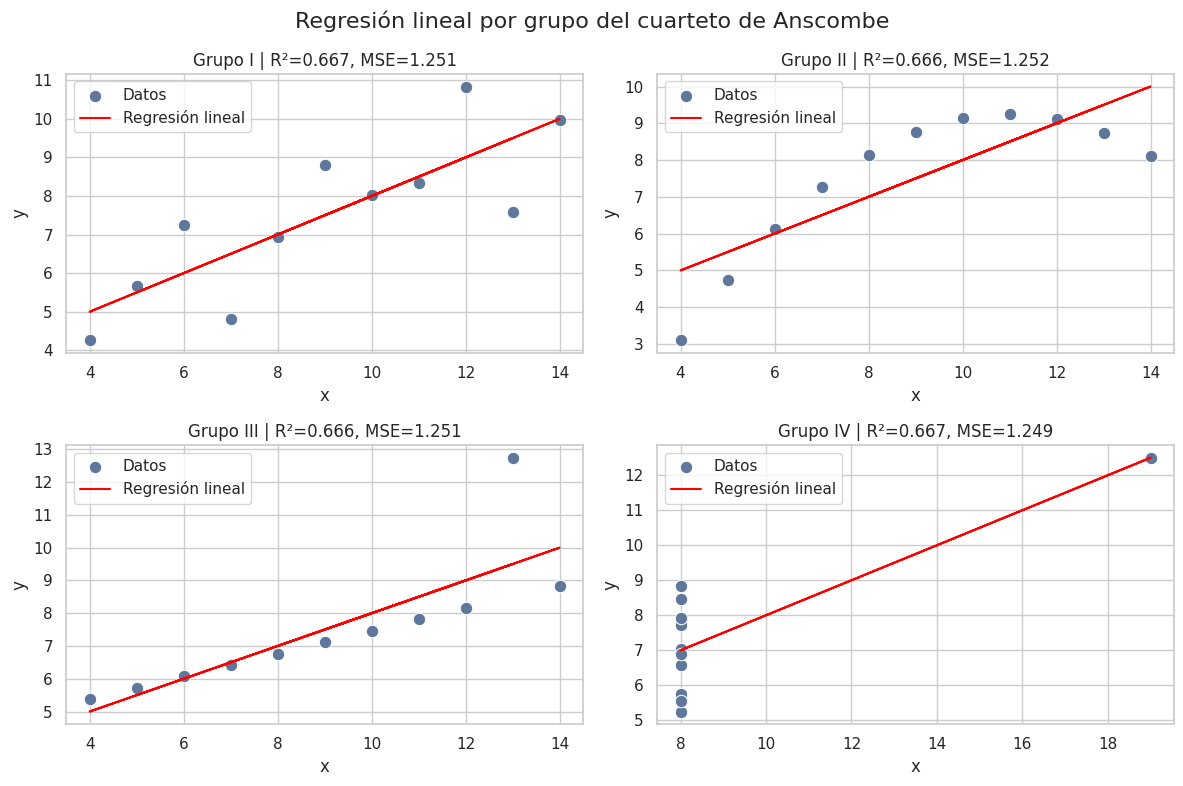

,dataset,intercepto,pendiente,MSE,R2
0,I,3.0001,0.5001,1.2512,0.6665
1,II,3.0009,0.5000,1.2524,0.6662
2,III,3.0025,0.4997,1.2506,0.6663
3,IV,3.0017,0.4999,1.2493,0.6667


In [4]:
# 3. Regresión lineal con sklearn para cada grupo

resultados_modelos = []

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, dataset in zip(axes, datasets):
    subset = data[data["dataset"] == dataset]

    X = subset[["x"]]
    y = subset["y"]

    # Entrenar modelo lineal
    model = LinearRegression()
    model.fit(X, y)

    # Predicciones
    y_pred = model.predict(X)

    # Métricas
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    resultados_modelos.append({
        "dataset": dataset,
        "intercepto": model.intercept_,
        "pendiente": model.coef_[0],
        "MSE": mse,
        "R2": r2
    })

    # Gráfico con recta de regresión
    sns.scatterplot(
        data=subset,
        x="x",
        y="y",
        ax=ax,
        s=80,
        label="Datos"
    )

    ax.plot(
        subset["x"],
        y_pred,
        color="red",
        label="Regresión lineal"
    )

    ax.set_title(f"Grupo {dataset} | R²={r2:.3f}, MSE={mse:.3f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

plt.suptitle("Regresión lineal por grupo del cuarteto de Anscombe", fontsize=16)
plt.tight_layout()
plt.show()

resultados_modelos = pd.DataFrame(resultados_modelos)
display(resultados_modelos.round(4))

Los modelos de regresión lineal entregan resultados prácticamente idénticos para los cuatro grupos. En todos los casos, el intercepto se encuentra cerca de 3, la pendiente se aproxima a 0,5, el MSE está alrededor de 1,25 y el R² es cercano a 0,666.

Esto significa que, desde el punto de vista de las métricas del modelo, los cuatro grupos parecen tener una calidad de ajuste muy similar. El R² cercano a 0,666 indica que la regresión lineal explica aproximadamente el 66,6% de la variabilidad de `y` en cada grupo.

Sin embargo, al comparar estos resultados con los gráficos de dispersión, se observa que esta conclusión puede ser engañosa. En el grupo I, la regresión lineal sí parece adecuada porque los datos siguen una tendencia aproximadamente recta. En cambio, en el grupo II, la relación es curva, por lo que la recta no captura bien el patrón. En el grupo III, la recta está afectada por un valor atípico. En el grupo IV, la relación depende de un punto influyente, ya que casi todos los valores de `x` son iguales.

Por lo tanto, aunque las métricas son casi iguales, la calidad real del modelo no es la misma en todos los grupos. Este resultado refuerza la importancia de visualizar los datos antes de interpretar una regresión.

4. Es evidente que el ajuste lineal no es adecuado para algunos grupos. Existen diversas estrategias para abordar este problema, como eliminar outliers o emplear diferentes modelos de regresión. Identifique una estrategia que podría mejorar el ajuste del modelo de regresión lineal y, si lo considera necesario, implemente otros modelos alternativos para aquellos casos donde el ajuste lineal resulte inadecuado.

Comparación Grupo II
Modelo lineal - MSE: 1.2524 R²: 0.6662
Modelo polinomial grado 2 - MSE: 0.0 R²: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


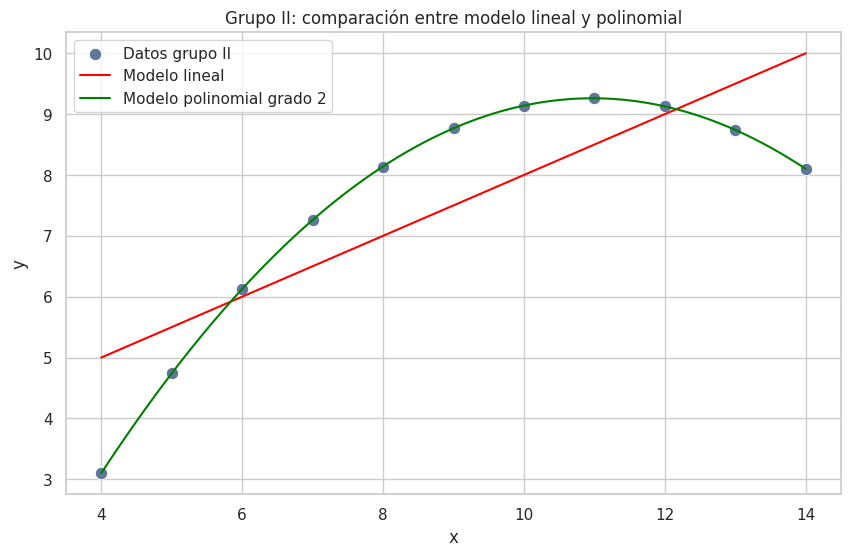


Comparación Grupo III
Con outlier - MSE: 1.2506 R²: 0.6663
Sin outlier - MSE: 0.0 R²: 1.0


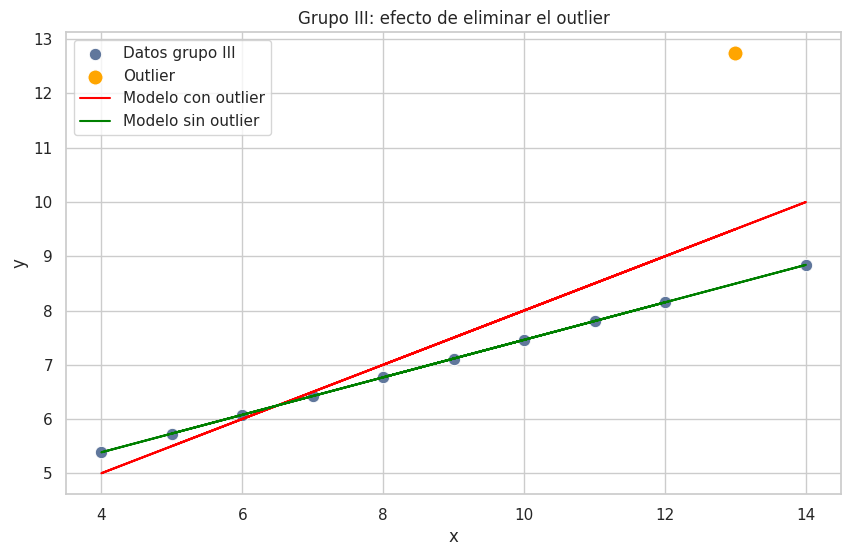


Grupo IV
En el grupo IV, la mayoría de los valores x son iguales y existe un punto influyente.
Eliminar el punto extremo puede dejar poca variabilidad en x, por lo que un modelo lineal no es adecuado para describir este grupo.


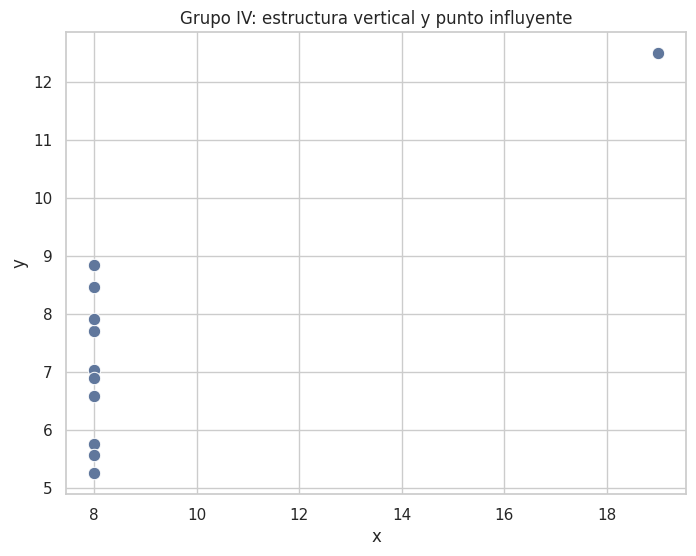

In [5]:
# 4. Estrategias alternativas para mejorar el ajuste

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Estrategia A: Modelo polinomial para el grupo II, porque presenta patrón curvo
grupo_II = data[data["dataset"] == "II"]

X_II = grupo_II[["x"]]
y_II = grupo_II["y"]

modelo_lineal_II = LinearRegression()
modelo_lineal_II.fit(X_II, y_II)
pred_lineal_II = modelo_lineal_II.predict(X_II)

modelo_poly_II = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
modelo_poly_II.fit(X_II, y_II)
pred_poly_II = modelo_poly_II.predict(X_II)

mse_lineal_II = mean_squared_error(y_II, pred_lineal_II)
r2_lineal_II = r2_score(y_II, pred_lineal_II)

mse_poly_II = mean_squared_error(y_II, pred_poly_II)
r2_poly_II = r2_score(y_II, pred_poly_II)

print("Comparación Grupo II")
print("Modelo lineal - MSE:", round(mse_lineal_II, 4), "R²:", round(r2_lineal_II, 4))
print("Modelo polinomial grado 2 - MSE:", round(mse_poly_II, 4), "R²:", round(r2_poly_II, 4))

# Graficar comparación para grupo II
x_range = np.linspace(X_II["x"].min(), X_II["x"].max(), 100).reshape(-1, 1)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=grupo_II, x="x", y="y", s=80, label="Datos grupo II")
plt.plot(x_range, modelo_lineal_II.predict(x_range), color="red", label="Modelo lineal")
plt.plot(x_range, modelo_poly_II.predict(x_range), color="green", label="Modelo polinomial grado 2")
plt.title("Grupo II: comparación entre modelo lineal y polinomial")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# Estrategia B: revisar influencia de outliers en grupos III y IV
# En grupo III se elimina el punto con y más alto.
grupo_III = data[data["dataset"] == "III"].copy()
grupo_III_sin_outlier = grupo_III.drop(grupo_III["y"].idxmax())

X_III = grupo_III[["x"]]
y_III = grupo_III["y"]

X_III_clean = grupo_III_sin_outlier[["x"]]
y_III_clean = grupo_III_sin_outlier["y"]

modelo_III = LinearRegression().fit(X_III, y_III)
modelo_III_clean = LinearRegression().fit(X_III_clean, y_III_clean)

pred_III = modelo_III.predict(X_III)
pred_III_clean = modelo_III_clean.predict(X_III_clean)

print("\nComparación Grupo III")
print("Con outlier - MSE:", round(mean_squared_error(y_III, pred_III), 4),
      "R²:", round(r2_score(y_III, pred_III), 4))
print("Sin outlier - MSE:", round(mean_squared_error(y_III_clean, pred_III_clean), 4),
      "R²:", round(r2_score(y_III_clean, pred_III_clean), 4))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=grupo_III, x="x", y="y", s=80, label="Datos grupo III")
sns.scatterplot(
    data=grupo_III.loc[[grupo_III["y"].idxmax()]],
    x="x",
    y="y",
    s=120,
    color="orange",
    label="Outlier"
)
plt.plot(grupo_III["x"], modelo_III.predict(X_III), color="red", label="Modelo con outlier")
plt.plot(grupo_III_sin_outlier["x"], modelo_III_clean.predict(X_III_clean), color="green", label="Modelo sin outlier")
plt.title("Grupo III: efecto de eliminar el outlier")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# Grupo IV: advertencia sobre estructura vertical y punto influyente
grupo_IV = data[data["dataset"] == "IV"].copy()

print("\nGrupo IV")
print("En el grupo IV, la mayoría de los valores x son iguales y existe un punto influyente.")
print("Eliminar el punto extremo puede dejar poca variabilidad en x, por lo que un modelo lineal no es adecuado para describir este grupo.")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=grupo_IV, x="x", y="y", s=80)
plt.title("Grupo IV: estructura vertical y punto influyente")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

En este punto se evaluaron estrategias alternativas para mejorar el ajuste del modelo en aquellos grupos donde la regresión lineal simple no representa adecuadamente los datos.

Para el **grupo II**, se comparó el modelo lineal con un modelo polinomial de grado 2. El modelo lineal obtuvo un MSE de 1,2524 y un R² de 0,6662, mientras que el modelo polinomial obtuvo un MSE de 0,0 y un R² de 1,0. Esto indica que el modelo polinomial captura perfectamente el patrón curvo del grupo II. Por lo tanto, en este caso, el problema no es la relación entre las variables, sino la elección de un modelo lineal cuando la relación real es no lineal.

Para el **grupo III**, se comparó el modelo con y sin el valor atípico. Con el outlier, el modelo obtuvo un MSE de 1,2506 y un R² de 0,6663. Al eliminar el punto atípico, el MSE baja a 0,0 y el R² sube a 1,0. Esto muestra que el outlier afectaba fuertemente la estimación del modelo. En este caso, la estrategia adecuada es revisar el valor atípico, analizar si corresponde a un error o a una observación válida, y decidir si debe mantenerse o excluirse.

En el **grupo IV**, se observa un problema distinto: la mayoría de los valores de `x` son iguales y existe un punto influyente que determina casi completamente la pendiente de la regresión. Esto significa que el modelo lineal no es confiable para describir este grupo, porque la relación estimada depende demasiado de una sola observación.

En conclusión, el punto 4 muestra que no siempre se debe aplicar una regresión lineal de forma automática. En algunos casos puede ser mejor usar modelos no lineales, como en el grupo II; en otros, revisar valores atípicos, como en el grupo III; y en otros, reconocer que la estructura de los datos no permite una regresión lineal confiable, como ocurre en el grupo IV.

### Conclusión general

El laboratorio demuestra que las estadísticas descriptivas y las métricas de regresión no siempre son suficientes para comprender correctamente un conjunto de datos. En el cuarteto de Anscombe, los cuatro grupos presentan medias, varianzas, correlaciones, pendientes, interceptos, MSE y R² muy similares. Sin embargo, sus gráficos muestran comportamientos completamente diferentes.

El **grupo I** es el único que se ajusta razonablemente bien a una regresión lineal simple. El **grupo II** presenta una relación curva, por lo que un modelo polinomial de grado 2 explica mucho mejor los datos, alcanzando un R² de 1,0. El **grupo III** está fuertemente influido por un outlier, ya que al eliminarlo el modelo logra un ajuste perfecto. El **grupo IV** depende de un punto influyente y no ofrece una estructura adecuada para interpretar una regresión lineal confiable.

La principal enseñanza del laboratorio es que antes de aplicar o interpretar un modelo de Machine Learning es necesario visualizar los datos. Las métricas pueden entregar resultados similares, pero los gráficos permiten detectar patrones no lineales, valores atípicos y puntos influyentes. Por lo tanto, un buen análisis debe combinar estadística descriptiva, visualización y evaluación del modelo.

Aunque los cuatro grupos presentan estadísticas y métricas de regresión muy parecidas, sus gráficos muestran patrones distintos. Esto demuestra que una regresión lineal no siempre es adecuada, incluso si el R² y el MSE parecen aceptables.

El grupo I puede modelarse razonablemente con una recta. El grupo II requiere un modelo polinomial porque tiene forma curva. El grupo III necesita revisión de outliers, ya que un punto atípico afecta el ajuste. El grupo IV no es adecuado para una regresión lineal tradicional, porque casi todos los valores de `x` son iguales y un solo punto influye en la pendiente.

Por lo tanto, la estrategia más importante es visualizar los datos antes de elegir el modelo. Según el patrón observado, se puede optar por una regresión lineal, un modelo polinomial, una revisión de outliers o incluso descartar el ajuste lineal si la estructura de los datos no lo permite.